# 30-Day Readmission Prediction: Logistic Regression
**Author:** Nafisa Tasnia  
**Project:** DS4400 — 30 Day Readmission Prediction in Diabetic Patients  
**Dataset:** Diabetes 130-US Hospitals 1999-2008

In [25]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import os

# sklearn — model building and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')
print('All imports successful.')

All imports successful.


Load Preprocessed Data

In [26]:
# Load all preprocessed data produced by 02_preprocessing.ipynb
_cwd = Path(os.getcwd())
ROOT = _cwd if (_cwd / 'data').exists() else _cwd.parent

PROCESSED_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR   = ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X_train_sc      = joblib.load(PROCESSED_DIR / 'X_train_sc.pkl')
X_test_sc       = joblib.load(PROCESSED_DIR / 'X_test_sc.pkl')
y_train_bal     = joblib.load(PROCESSED_DIR / 'y_train_bal.pkl')
y_test          = joblib.load(PROCESSED_DIR / 'y_test.pkl')
feature_names   = joblib.load(PROCESSED_DIR / 'feature_names.pkl')
SMOTE_AVAILABLE = joblib.load(PROCESSED_DIR / 'smote_available.pkl')

print(f'Train : {X_train_sc.shape}  |  Test : {X_test_sc.shape}')
print(f'Train positive rate : {y_train_bal.mean():.3f}')
print(f'Test  positive rate : {y_test.mean():.3f}')
print(f'SMOTE applied       : {SMOTE_AVAILABLE}')

Train : (76538, 44)  |  Test : (19135, 44)
Train positive rate : 0.115
Test  positive rate : 0.115
SMOTE applied       : False


## Logistic Regression: Baseline Model

In [27]:
# If SMOTE balanced the training data, we don't need class_weight='balanced' too —
# using both would over-correct. If SMOTE wasn't available, set it here instead.
class_weight_setting = None if SMOTE_AVAILABLE else 'balanced'

# Baseline model with mostly default settings — we'll tune this in section 10.
# lbfgs is a good general-purpose solver for medium-sized datasets.
# max_iter=1000 gives it plenty of room to converge — 100 is often not enough.
lr_base = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    class_weight=class_weight_setting,
    random_state=42
)
lr_base.fit(X_train_sc, y_train_bal)
print('Baseline model trained.')

Baseline model trained.



 Logistic Regression (Baseline) 
  Accuracy  : 0.6658
  Precision : 0.1802
  Recall    : 0.5351
  F1 Score  : 0.2696
  ROC-AUC   : 0.6500

Classification Report:
              precision    recall  f1-score   support

    Not <30d       0.92      0.68      0.78     16930
Readmit <30d       0.18      0.54      0.27      2205

    accuracy                           0.67     19135
   macro avg       0.55      0.61      0.53     19135
weighted avg       0.83      0.67      0.72     19135



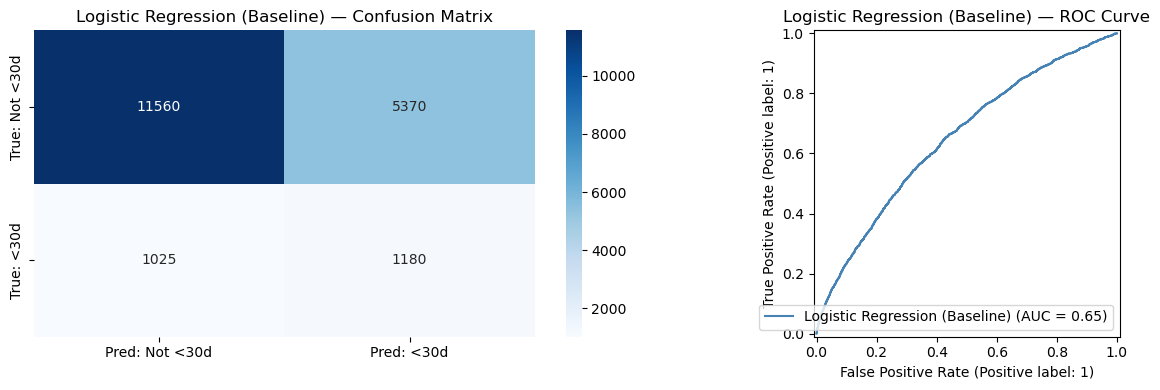

In [35]:
def evaluate_model(model, X_test_scaled, y_test, model_name='Model'):
    """
    Runs predictions and prints all our key metrics, plus a confusion matrix
    and ROC curve. Returns the metrics as a dict so we can compare models later.
    """
    y_pred = model.predict(X_test_scaled)
    # predict_proba gives us the probability of class 1, needed for ROC-AUC
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred)
    rec   = recall_score(y_test, y_pred)
    roc   = roc_auc_score(y_test, y_prob)
    cm    = confusion_matrix(y_test, y_pred)

    print(f'\n {model_name} ')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')  # of patients we flagged, how many were actually readmitted?
    print(f'  Recall    : {rec:.4f}')   # of patients who were actually readmitted, how many did we catch?
    print(f'  F1 Score  : {f1:.4f}')   # harmonic mean of precision and recall
    print(f'  ROC-AUC   : {roc:.4f}')  # overall discriminative power across all thresholds
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Not <30d', 'Readmit <30d']))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Confusion matrix — lets us see the actual vs predicted breakdown
    # Top-left = true negatives, bottom-right = true positives
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: Not <30d', 'Pred: <30d'],
                yticklabels=['True: Not <30d', 'True: <30d'], ax=axes[0])
    axes[0].set_title(f'{model_name} — Confusion Matrix')

    # ROC curve — the closer it hugs the top-left corner, the better
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                      name=model_name, color='steelblue')
    axes[1].set_title(f'{model_name} — ROC Curve')

    plt.tight_layout()
    fname = RESULTS_DIR / (model_name.lower().replace(' ', '_') + '_eval.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec, 'roc_auc': roc}

baseline_metrics = evaluate_model(lr_base, X_test_sc, y_test, 'Logistic Regression (Baseline)')

## Hyperparameter Tuning (GridSearchCV)

In [29]:
# C controls regularization strength — smaller C = more regularization = simpler model.
# L1 penalty (lasso) can zero out irrelevant features entirely (built-in feature selection).
# L2 penalty (ridge) shrinks all coefficients but keeps them all non-zero.
# We test both to see which works better for this dataset.
# Note: L1 only works with the 'liblinear' and 'saga' solvers, not 'lbfgs'.
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
}

# StratifiedKFold keeps the class ratio consistent across folds —
# especially important with an imbalanced dataset like ours
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# We optimize for F1 rather than accuracy because accuracy alone is misleading
# when classes are imbalanced (a model that always predicts 0 still gets 89% accuracy)
grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight=class_weight_setting, random_state=42),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,   # use all available CPU cores to speed this up
    verbose=1
)

grid_search.fit(X_train_sc, y_train_bal)

print(f'\nBest parameters: {grid_search.best_params_}')
print(f'Best CV F1 score: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1 score: 0.2619



===== Logistic Regression (Tuned) =====
  Accuracy  : 0.6708
  Precision : 0.1822
  Recall    : 0.5324
  F1 Score  : 0.2715
  ROC-AUC   : 0.6513

Classification Report:
              precision    recall  f1-score   support

    Not <30d       0.92      0.69      0.79     16930
Readmit <30d       0.18      0.53      0.27      2205

    accuracy                           0.67     19135
   macro avg       0.55      0.61      0.53     19135
weighted avg       0.83      0.67      0.73     19135



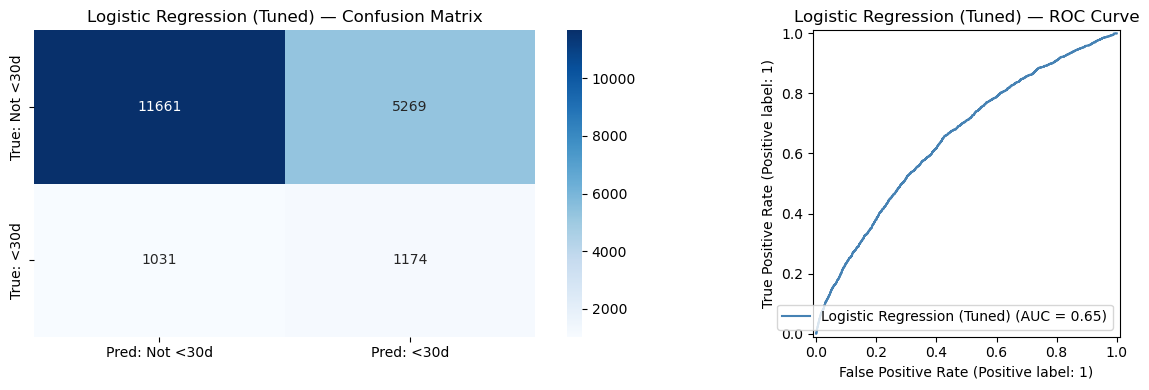

In [30]:
# Grab the best model from the grid search and evaluate it on the held-out test set
best_lr = grid_search.best_estimator_
tuned_metrics = evaluate_model(best_lr, X_test_sc, y_test, 'Logistic Regression (Tuned)')

## Cross-Validation on Tuned Model

5-Fold CV F1 scores: [0.2729805  0.25662809 0.26755853 0.25764001 0.25491898]
Mean CV F1: 0.2619 ± 0.0071


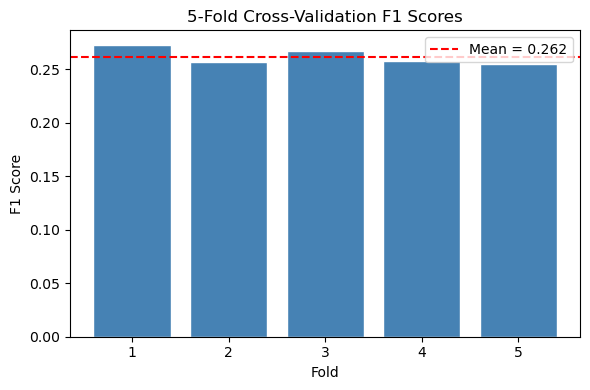

In [31]:
# Run 5-fold CV one more time on the final model to get a stable estimate of performance.
# The standard deviation across folds tells us how consistent the model is —
# high variance between folds could mean the model is sensitive to which data it sees.
cv_scores = cross_val_score(best_lr, X_train_sc, y_train_bal, cv=cv, scoring='f1', n_jobs=-1)

print(f'5-Fold CV F1 scores: {cv_scores}')
print(f'Mean CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title('5-Fold Cross-Validation F1 Scores')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cv_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance (Coefficients)

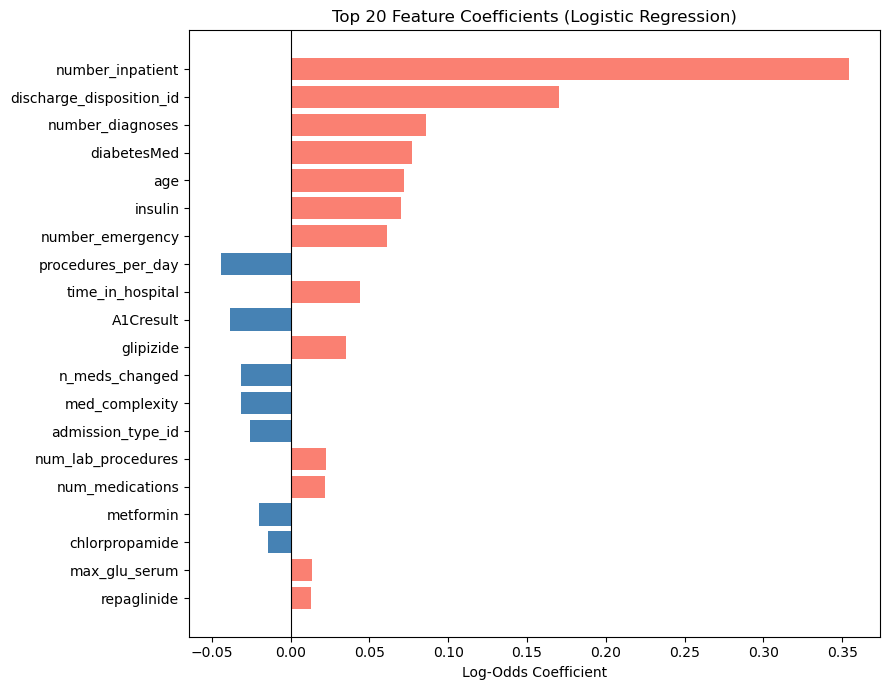


Top 20 features by absolute coefficient:
                 feature  coefficient
        number_inpatient     0.353996
discharge_disposition_id     0.170367
        number_diagnoses     0.085897
             diabetesMed     0.076833
                     age     0.071844
                 insulin     0.069876
        number_emergency     0.060991
      procedures_per_day    -0.044475
        time_in_hospital     0.043898
               A1Cresult    -0.038271
               glipizide     0.035010
          n_meds_changed    -0.031221
          med_complexity    -0.031221
       admission_type_id    -0.025703
      num_lab_procedures     0.022491
         num_medications     0.021567
               metformin    -0.019993
          chlorpropamide    -0.014596
           max_glu_serum     0.013349
             repaglinide     0.013098


In [32]:
# One of the big advantages of logistic regression over tree-based models is interpretability.
# Each coefficient tells us the change in log-odds of readmission for a 1-unit increase
# in that feature (after scaling, so units are standard deviations).
#
# Positive coefficient → feature increases readmission risk
# Negative coefficient → feature decreases readmission risk
feature_names = X.columns.tolist()
coefs = best_lr.coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)  # rank by importance

top_n = 20
top_features = coef_df.head(top_n)

plt.figure(figsize=(9, 7))
# Color bars by direction: salmon = increases risk, blue = decreases risk
colors = ['salmon' if c > 0 else 'steelblue' for c in top_features['coefficient']]
plt.barh(top_features['feature'][::-1], top_features['coefficient'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)  # zero line for reference
plt.xlabel('Log-Odds Coefficient')
plt.title(f'Top {top_n} Feature Coefficients (Logistic Regression)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 20 features by absolute coefficient:')
print(coef_df[['feature', 'coefficient']].head(20).to_string(index=False))

## Summary Table

 Model Comparison
             accuracy      f1  precision  recall  roc_auc
Model                                                    
LR Baseline    0.6658  0.2696     0.1802  0.5351   0.6500
LR Tuned       0.6708  0.2715     0.1822  0.5324   0.6513


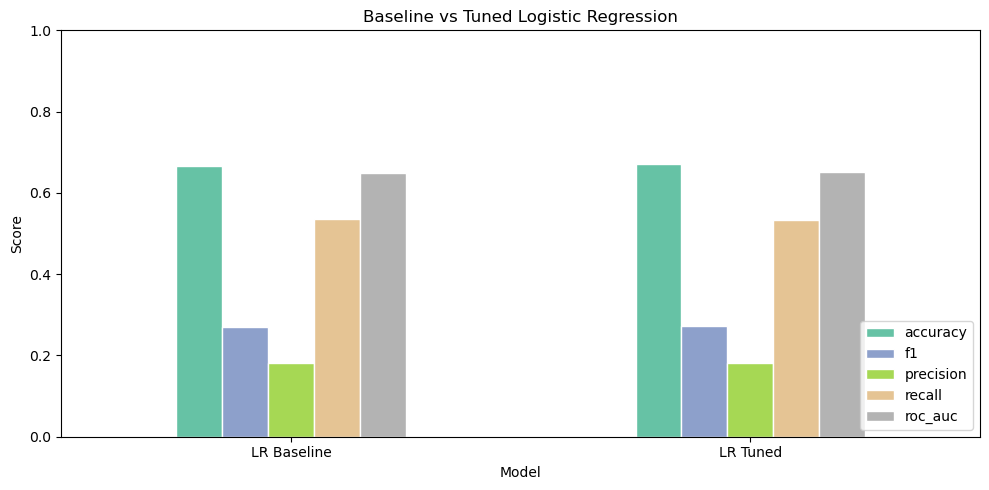

In [34]:
# Side-by-side comparison to see how much tuning actually helped
summary = pd.DataFrame([
    {'Model': 'LR Baseline', **baseline_metrics},
    {'Model': 'LR Tuned',    **tuned_metrics},
]).set_index('Model').round(4)

print(' Model Comparison')
print(summary.to_string())

summary.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Baseline vs Tuned Logistic Regression')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Key Findings

- **Target variable** was binarised as `1` if `readmitted == '<30'`, else `0`.
- The dataset is **heavily imbalanced** (~11% positive class); handled via SMOTE (or `class_weight='balanced'`).
- **Preprocessing steps:** dropped high-missingness columns (`weight`, `payer_code`, `medical_specialty`); imputed remaining nulls; encoded ICD-9 codes into broad categories; label-encoded medications and binary features; one-hot encoded race & diagnosis categories.
- **Feature engineering:** added `total_prior_visits`, `n_meds_changed`, `med_complexity`, and `procedures_per_day`.
- **Tuning** via 5-fold stratified GridSearchCV over `C ∈ {0.01, 0.1, 1, 10}` and L1/L2 penalty.
- **Strongest predictors** (see coefficient plot): prior inpatient admissions, number of diagnoses, time in hospital, and certain discharge/admission type codes.

> Logistic Regression provides a transparent, interpretable baseline well-suited for clinical settings where model explainability matters.